# Free Parking Space - YOLOv11

In this project, the total number of available parking spaces in the parking lot is calculated and updated in real time.

The main goal of the project is to calculate the total number of empty parking spaces after vehicles enter the parking lot and occupy available spaces.

The important part of this project is detecting whether a vehicle enters one of the selected green areas. If a vehicle enters one of these areas, that parking space should be subtracted from the total number of available parking spaces.

In projects like this, the camera angle must remain fixed.

**Now, first we should move to the other notebook and examine and edit the ROI selection notebook, meaning the Region of Interest selection notebook.**


**Please go to the `ROI_selection` notebook, create the coordinates, and then return here.**

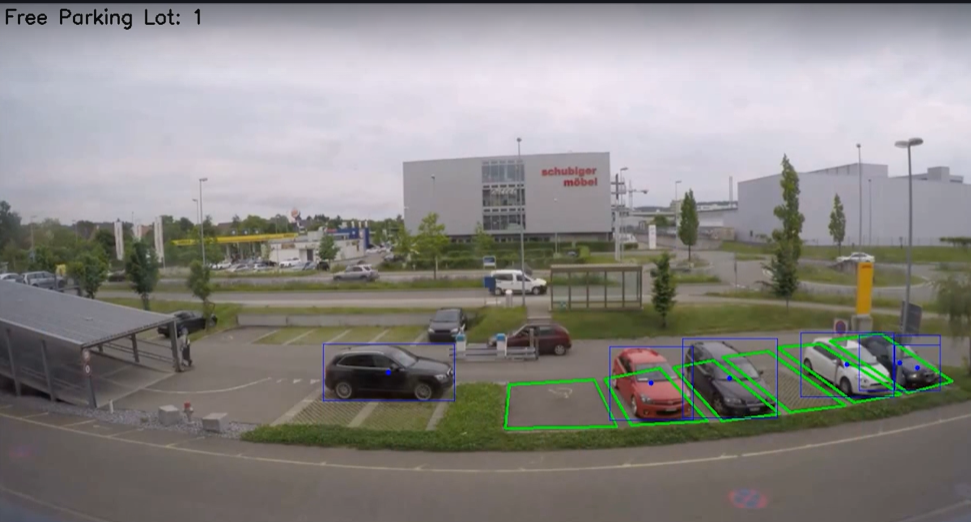

**General Mind Map** is provided here, and the detailed version is available in the related folder.


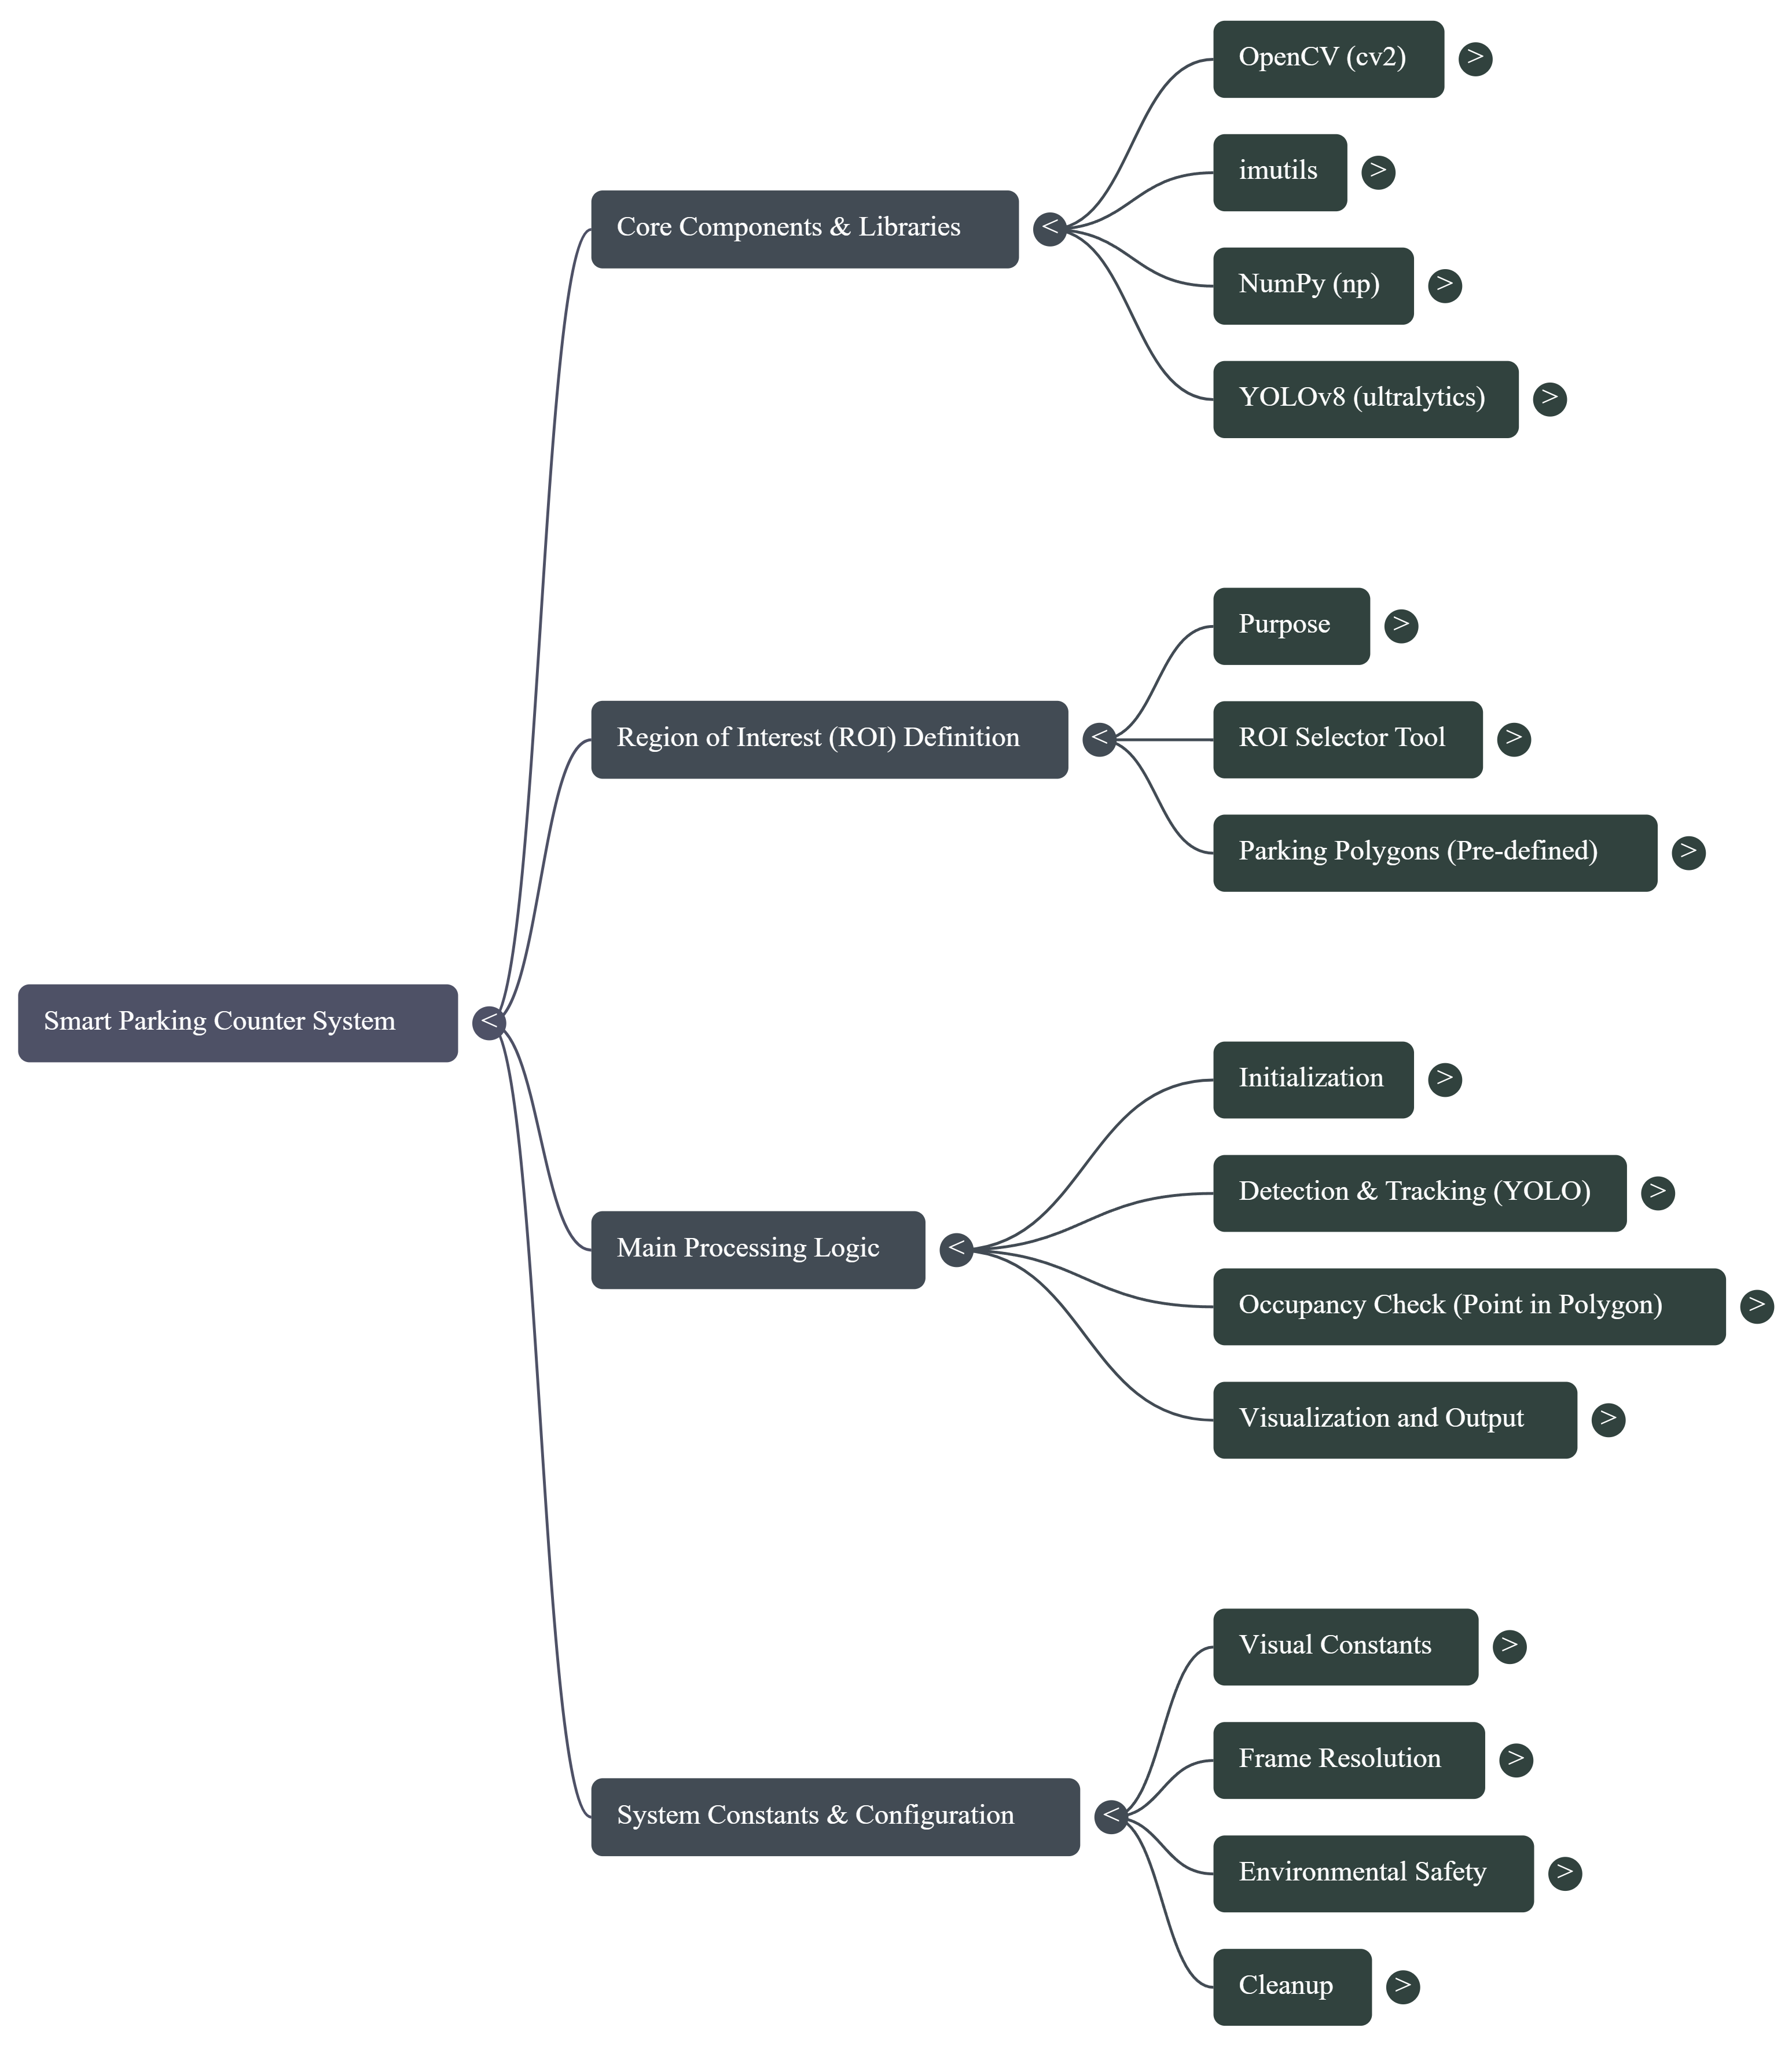

## 1. Importing the Required Libraries and Environment Settings


In [1]:
import os

# [EXPERT NOTE] This setting is used to prevent possible library conflicts,
# such as the "OMP: Error #15" error.

# It is a safety precaution to help the code run properly.

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
import cv2  # OpenCV for image processing

import imutils  # Helper tools for OpenCV, such as resizing

import numpy as np  # Used for numerical operations and array management

from ultralytics import YOLO  # Used to load and run the YOLO model

## 2. Visualization Constants: Colors and Fonts


In [6]:
# We define the colors that will be used for drawing in BGR format,
# which stands for Blue, Green, Red and is the color format used by OpenCV.

blue = (255, 0, 0)
green = (0, 255, 0)
red = (0, 0, 255)
black = (0, 0, 0)
white = (255, 255, 255)

thickness = 2  # Thickness of the lines, such as polygons and boxes
font_scale = 0.6  # Text size
font = cv2.FONT_HERSHEY_SIMPLEX  # Font type to be used

## 3. Parking Space State Variables


In [9]:
# We create a dictionary for each parking space polygon.
# These dictionaries can be used to track which vehicle, identified by its `track_id`,
# is currently inside which parking space.

# In this code, they are used for real-time counting.

# In the parking lot, 6 areas were selected as ROIs.

polygon_1_dict = {}
polygon_2_dict = {}
polygon_3_dict = {}
polygon_4_dict = {}
polygon_5_dict = {}
polygon_6_dict = {}

In [11]:
# We will only consider the vehicle classes in the COCO dataset:
# car, motorcycle, bus, and truck.

vehicles = [2, 3, 5, 7]

## 4. Defining the Region of Interest (ROI) Polygons


In [14]:
# [EXPERT NOTE] This is the most critical part of the project.

# We manually define the corner coordinates of each parking space
# in the parking lot as pixel values.

# These coordinates are adjusted according to the frame width of 1280,
# which is set by `imutils.resize(frame, width=1280)`.

# The `np.int32` data type is the data type expected by OpenCV's polygon functions.

# We enter the coordinates obtained in the ROI selection step into the areas below.

# If there is a problem in the video flow after this code,
# for example if the vehicle entering the parking area is not detected clearly,
# we can adjust these coordinates.

polygon_1 = np.array([[634, 471], [629, 525],
                      [767, 523], [739, 465]], np.int32)

polygon_2 = np.array([[752, 464], [785, 521],
                      [879, 516], [820, 451]], np.int32)

polygon_3 = np.array([[897, 516], [837, 450],
                      [886, 441], [968, 507]], np.int32)

polygon_4 = np.array([[981, 505], [898, 437],
                      [954, 430], [1049, 497]], np.int32)

polygon_5 = np.array([[1060, 493], [965, 425],
                      [1018, 421], [1118, 483]], np.int32)

polygon_6 = np.array([[1127, 481], [1030, 417],
                      [1093, 408], [1181, 467]], np.int32)

## 5. Video Input and Model Loading


In [17]:
video_path = "inference/test.mp4"

cap = cv2.VideoCapture(video_path)  # Object used to read the video file

model = YOLO("models/yolo11s.pt")  # We load the YOLOv11 "small" model.
# If needed, stronger models can also be used.

## 6. Video Output / Writing Settings


In [20]:
width = 1280
height = 720

# The resolution of the output video should be the same as the processed frame.

In [22]:
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec used for saving the video

# Create the output video file
writer = cv2.VideoWriter("video_output.avi", fourcc, 20.0, (width, height))

## 7. Main Processing Loop


In [25]:
# The `free_space_counter` list will be used to count the parking spaces
# that are occupied in each frame.

# It must be defined inside the loop or reset in each loop.
# In this code, it is reset at the end of the loop.

free_space_counter = []

When the code block below runs, a new window will open.

In the video, the number of available parking spaces will be shown in real time at the top-left corner of the screen.


In [28]:
while True:
    # Read one frame from the video
    ret, frame = cap.read()
    if ret == False:
        break  # If the video has ended, exit the loop

    # Resize the frame to a standard size, with a width of 1280.
    # This ensures that our polygon coordinates always remain consistent.
    
    frame = imutils.resize(frame, width=1280)

    
    # [IMPORTANT] We create a copy of the original frame.
    # Reason: It is better for the YOLO model to run on a "clean" frame,
    # meaning a frame without any drawings on it.
    # We will draw all visual elements, such as polygons and text, on `frame_copy`.
    
    frame_copy = frame.copy()

    
    # --- 8. Drawing the Parking Space Polygons ---
    
    # We draw the 6 parking spaces that we defined on `frame_copy` in green.
    
    cv2.polylines(frame_copy, [polygon_1], isClosed=True, color=green, thickness=thickness)
    cv2.polylines(frame_copy, [polygon_2], isClosed=True, color=green, thickness=thickness)
    cv2.polylines(frame_copy, [polygon_3], isClosed=True, color=green, thickness=thickness)
    cv2.polylines(frame_copy, [polygon_4], isClosed=True, color=green, thickness=thickness)
    cv2.polylines(frame_copy, [polygon_5], isClosed=True, color=green, thickness=thickness)
    cv2.polylines(frame_copy, [polygon_6], isClosed=True, color=green, thickness=thickness)

    # --- 9. Object Detection and Tracking with YOLOv11 ---
    
    # We run the model on the original `frame`.
    results = model.track(frame, persist=True, verbose=False)[0]
    
    # We convert the detected boxes, or bounding boxes, into a NumPy array.
    bboxes = np.array(results.boxes.data.tolist(), dtype="int")

    # --- 10. Processing the Detected Vehicles ---
    
    for box in bboxes:
        # Get the bounding box information
        x1, y1, x2, y2, track_id, score, class_id = box
       
        # Calculate the center point, or centroid, of the vehicle.
        # We use the center point as the main reference point for the vehicle.
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        # If the detected object is a vehicle, meaning it is in the `vehicles` list,
        # we continue by using the center point because it is important
        # for detecting whether the vehicle is inside a parking area.
        if class_id in vehicles:
            
            # Draw a blue circle at the center of the vehicle
            cv2.circle(frame_copy, (cx, cy), 3, blue, -1)
            
            # Draw a blue detection box around the vehicle
            cv2.rectangle(frame_copy, (x1, y1), (x2, y2), blue, thickness=1)

            # --- 11. Occupancy Check: Point-in-Polygon Test ---
            
            # [MAIN LOGIC]
             
            # With the `cv2.pointPolygonTest` function, we check whether
            # the vehicle's center point, (cx, cy), is inside the polygons we defined.
            #
            # If `measureDist=False`:
            #   Result >= 0 means the point is inside the polygon or on its edge.
            #   Result < 0, usually -1, means the point is outside the polygon.
            
            polygon_1_result = cv2.pointPolygonTest(polygon_1, (cx, cy), measureDist=False)
            polygon_2_result = cv2.pointPolygonTest(polygon_2, (cx, cy), measureDist=False)
            polygon_3_result = cv2.pointPolygonTest(polygon_3, (cx, cy), measureDist=False)
            polygon_4_result = cv2.pointPolygonTest(polygon_4, (cx, cy), measureDist=False)
            polygon_5_result = cv2.pointPolygonTest(polygon_5, (cx, cy), measureDist=False)
            polygon_6_result = cv2.pointPolygonTest(polygon_6, (cx, cy), measureDist=False)
            
            # If the vehicle is detected inside a polygon,
            # we add the vehicle's ID to that polygon's dictionary
            # and add one item to the "occupied" counter.

            if polygon_1_result >= 0:
                polygon_1_dict[track_id] = x1, y1, x2, y2
                free_space_counter.append(polygon_1_dict)  # Mark it as occupied

            if polygon_2_result >= 0:
                polygon_2_dict[track_id] = x1, y1, x2, y2
                free_space_counter.append(polygon_2_dict)

            if polygon_3_result >= 0:
                polygon_3_dict[track_id] = x1, y1, x2, y2
                free_space_counter.append(polygon_3_dict)

            if polygon_4_result >= 0:
                polygon_4_dict[track_id] = x1, y1, x2, y2
                free_space_counter.append(polygon_4_dict)

            if polygon_5_result >= 0:
                polygon_5_dict[track_id] = x1, y1, x2, y2
                free_space_counter.append(polygon_5_dict)

            if polygon_6_result >= 0:
                polygon_6_dict[track_id] = x1, y1, x2, y2
                free_space_counter.append(polygon_6_dict)

    
    # --- 12. Calculating and Displaying the Results ---
    
    # Number of free parking lots =
    # total number of parking spaces, which is 6 in this project,
    # minus the number of currently occupied spaces.
    #
    # `len(free_space_counter)` gives us how many vehicles are inside
    # the polygons in the current frame.
    
    free_lot = 6 - len(free_space_counter)  # At the beginning, there were 6 empty spaces
    
    # [VERY IMPORTANT] Before moving to the next frame, we reset the counter.
    # This ensures that the count is not cumulative.
    # Instead, the count is real-time and specific to the current frame.
    
    free_space_counter.clear()

    
    # Display the number of free parking spaces in the top-left corner of the screen
    
    text = "Free Parking Lot: {}".format(free_lot)
    cv2.putText(frame_copy, text, (10, 25), font, 0.8, black, thickness)

    # --- 13. Saving and Displaying ---
    
    # Write the processed frame, which includes the drawings on `frame_copy`,
    # to the output video file.
    writer.write(frame_copy)
    
    # Display the processed frame on the screen
    cv2.imshow("Free Parking Space Counter", frame_copy)
    
    # If the `q` key is pressed, exit the loop
    if cv2.waitKey(10) & 0xFF == ord("q"):
        break

## 14. Cleanup

In [30]:
# Release the video reader
cap.release()

# Release the video writer.
# This is required to make sure the file is saved properly.
writer.release()

# Close all OpenCV windows
cv2.destroyAllWindows()

print("[INFO]... Processing completed!")

[INFO]...İşleme tamamlandı!
